bs from state: [<VertexPropertyMap object with value type 'int64_t', for Graph 0x7fdd5f208350, at 0x7fdd5f213700>, PropertyArray([0, 1, 1]), PropertyArray([0, 0])]
Level 0 block labels: <VertexPropertyMap object with value type 'int64_t', for Graph 0x7fdd5f208350, at 0x7fdd5f213700>
Level 1 block labels: [0 1 1]
Level 2 block labels: [0 0]
Level 0 has B = 3 blocks
Level 1 has B = 2 blocks
Level 2 has B = 1 blocks


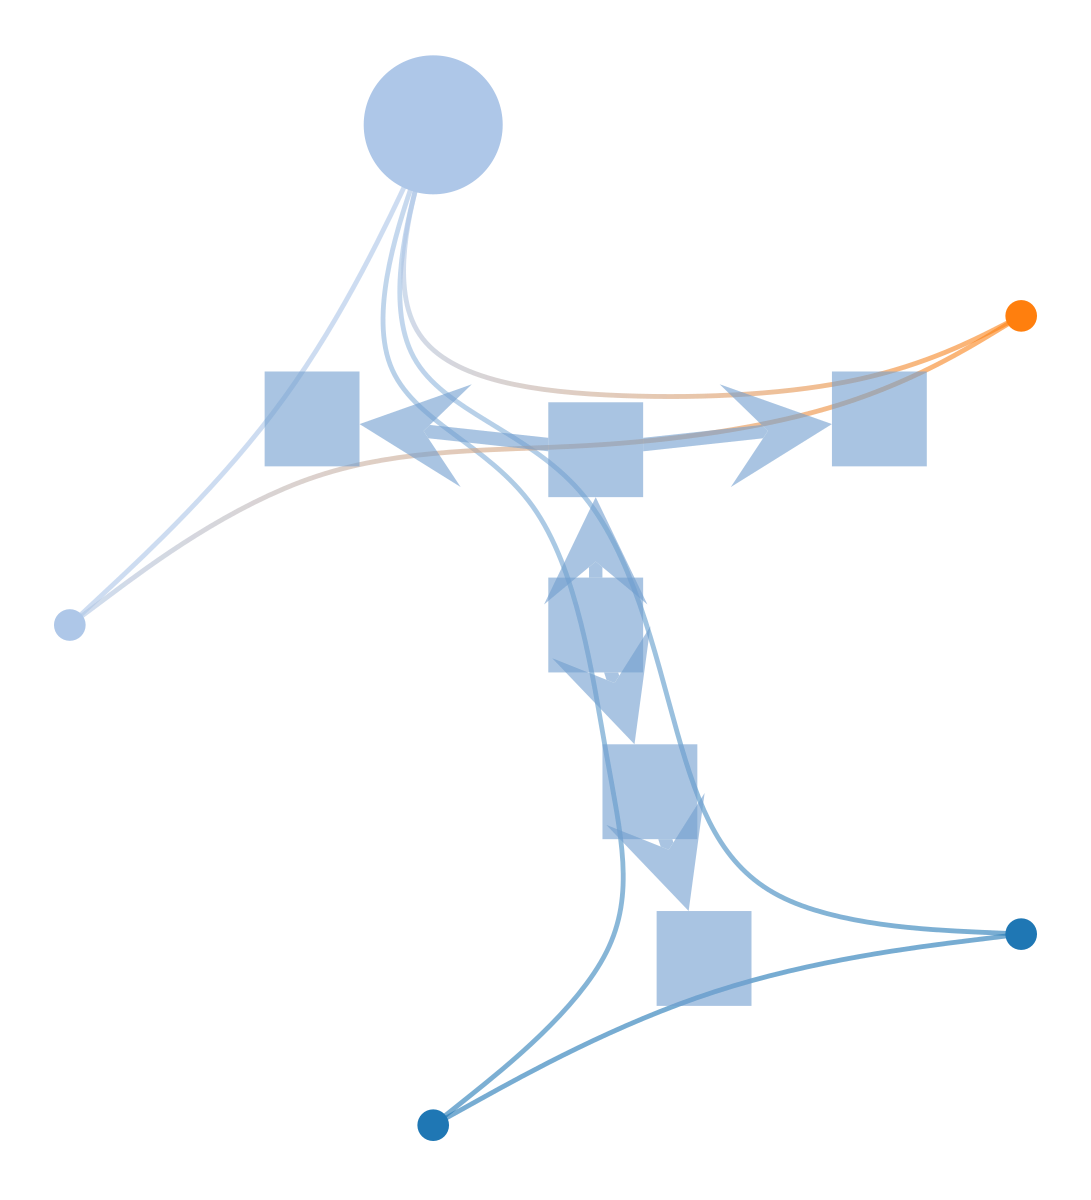

Hierarchy drawn to hierarchy.png


In [2]:
import graph_tool.all as gt
import numpy as np

# Create a small graph of 5 nodes (undirected)
g = gt.Graph(directed=False)
g.add_vertex(5)
# add a few edges (these are arbitrary—just to have a non‐empty graph)
edges = [(0,1), (0,2), (1,2), (2,3), (3,4), (2,4)]
for u,v in edges:
    g.add_edge(u, v)

# Now define your desired nested grouping:

# Level 0 (finest): each vertex → block
# blocks: {0,1}, {2,3}, {4}
blk0 = np.array([0,0, 1,1, 2], dtype=int)

# Level 1: map each block of level 0 → a superblock
# So block 0 (i.e. nodes 0&1) → superblock 0
#    block 1 (nodes 2&3) → superblock 1
#    block 2 (node 4 alone) → superblock 1  (i.e. grouped with block 1)
blk1 = np.array([0, 1, 1], dtype=int)
# (Length = number of level-0 blocks = 3)st

# Level 2: map each block from level 1 → a top block
# We want all blocks to be merged: so blk1-blocks 0 & 1 → superblock 0
blk2 = np.array([0, 0], dtype=int)
# (Length = number of level-1 blocks = 2)

# Combine into bs list
bs = [blk0, blk1, blk2]

# Now create a NestedBlockState with your custom hierarchy
state = gt.NestedBlockState(g, bs=bs)

# (Alternatively, you could do `state = gt.NestedBlockState(g)` then `state.set_state(bs)`)

# Let’s inspect / verify
print("bs from state:", state.get_bs())
# The get_bs() output should match what you passed (up to label‐shuffling)

# Show block memberships at level 0
print("Level 0 block labels:", state.get_bs()[0])
# And at higher levels:
print("Level 1 block labels:", state.get_bs()[1])
print("Level 2 block labels:", state.get_bs()[2])

# You can also retrieve the BlockState objects for each level:
levels = state.get_levels()
for lv, b in enumerate(levels):
    print(f"Level {lv} has B = {b.get_nonempty_B()} blocks")

# You can draw the hierarchy if you like (requires a graphical backend)
state.draw()  # saves to file
print("Hierarchy drawn to hierarchy.png")


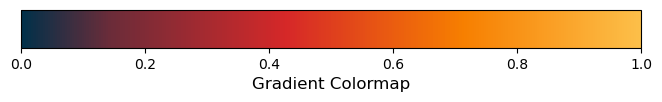

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Define your color stops
colors = ["#003049", "#6b2c39", "#a12a31", "#d62828", "#e75414", "#f77f00", "#fa9f25", "#fcbf49"]

# Create a continuous (gradient) colormap
gradient_cmap = LinearSegmentedColormap.from_list("gradient_palette", colors, N=256)

# Optional: register it globally
# plt.register_cmap("gradient_palette", gradient_cmap)

# Display the gradient
fig, ax = plt.subplots(figsize=(8, 1))
fig.subplots_adjust(bottom=0.5)

cb = plt.colorbar(
    plt.cm.ScalarMappable(cmap=gradient_cmap),
    cax=ax,
    orientation='horizontal'
)
cb.set_label("Gradient Colormap", fontsize=12)
plt.show()


## IPLOTX groups

In [10]:
list({"cluster A": "lightblue", "cluster B": "lightgreen"}.values())

['lightblue', 'lightgreen']

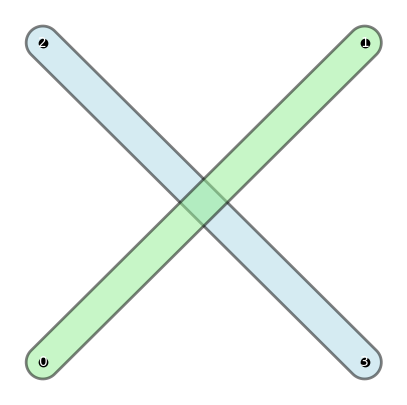

In [8]:
import iplotx as ipx
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5,5))

pos = {0: np.array([0,0]), 1: np.array([1,1]), 2: np.array([0,1]), 3: np.array([1,0])}

# ---- your custom network drawing here ----
# For example:
for i, p in pos.items():
    ax.scatter(*p, color="black")
    ax.text(*p, str(i), ha="center", va="center", color="white")
# -------------------------------------------
grouping={
        "cluster B": {2, 3},
        "cluster A": {0, 1},
    }
grouping_facecolor = {"cluster B": "lightblue", "cluster A": "lightgreen"}
# make the colors a list in the order of grouping keys
grouping_facecolor = {k: grouping_facecolor[k] for k in grouping.keys()}

# Now add ONLY the grouping layer from iplotx
ipx.network(
    grouping=grouping,
    layout=pos,                   # pass your dict of positions
    ax=ax,
    grouping_facecolor=list(grouping_facecolor.values()),
    grouping_edgecolor="black",
    grouping_linewidth=2,
    grouping_vertexpadding=12,
    zorder=-1,                    # draw underneath your nodes
)

plt.show()
